# Classification binaire : prédire le podium (Top 3)

> Objectif : prédire si un pilote termine dans le top 3 (`podium` : 1 = oui, 0 = non).

Ce notebook simule la structure de `f.ipynb` en utilisant le dataset `prepared_data.csv`.

Modèles testés (avec **Grid Search** et **Random Search**) :
- KNN
- SVM
- Decision Tree
- Random Forest
- XGBoost

Le notebook est exécutable bout à bout et affiche, pour chaque modèle/méthode : meilleurs hyperparamètres, métriques, matrice de confusion et courbe ROC.

In [3]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ImportError: cannot import name 'tarfile_extractall' from 'sklearn.utils.fixes' (c:\Users\oussa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\fixes.py)

In [ ]:
# Chargement des données
DATA_PATH = 'prepared_data.csv'
df = pd.read_csv(DATA_PATH)
print('Shape :', df.shape)
df.head()

Shape : (26487, 16)


,year,round,grid,qualifying_position,driver_standing_pos,driver_points_cum,driver_wins_cum,constructor_standing_pos,constructor_points_cum,constructor_wins_cum,country,podium,position_class,finish_pos_penalty,country_encoded,position_class_encoded
0,2008,1,1,1.0,1.0,10.0,1.0,1.0,14.0,1.0,Australia,1,0,1,1,0
1,2008,1,5,5.0,2.0,8.0,0.0,3.0,8.0,0.0,Australia,1,1,2,1,1
2,2008,1,7,7.0,3.0,6.0,0.0,2.0,9.0,0.0,Australia,1,1,3,1,1
3,2008,1,11,12.0,4.0,5.0,0.0,4.0,5.0,0.0,Australia,0,2,4,1,2
4,2008,1,3,3.0,5.0,4.0,0.0,1.0,14.0,1.0,Australia,0,2,5,1,2


In [ ]:
# Définition de la cible et des variables explicatives
TARGET = 'podium'
assert TARGET in df.columns, f"Colonne cible '{TARGET}' absente du dataset"

# Variables de fuite de cible à exclure
LEAKAGE_COLS = [
    'position_class',
    'finish_pos_penalty',
    'position_class_encoded'
]

cols_to_drop = [c for c in LEAKAGE_COLS if c in df.columns]
print('Colonnes exclues (fuite de cible) :', cols_to_drop)

X = df.drop(columns=[TARGET] + cols_to_drop)
y = df[TARGET].astype(int)

print('X shape:', X.shape)
print('y distribution:\n', y.value_counts(normalize=True).rename('proportion'))

Colonnes exclues (fuite de cible) : ['position_class', 'finish_pos_penalty', 'position_class_encoded']
X shape: (26487, 12)
y distribution:
 podium
0    0.873221
1    0.126779
Name: proportion, dtype: float64


In [ ]:
# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (21189, 12) Test: (5298, 12)


## Prétraitement et Fonctions réutilisables

In [ ]:
# Identification des colonnes
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numériques: {len(numeric_features)}, Catégorielles: {len(categorical_features)}')

# Pipelines de transformation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Validation croisée
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

Numériques: 11, Catégorielles: 1


In [ ]:
def evaluate_binary_classification(best_estimator, X_test, y_test, title=''):
    """Calcule les métriques + affiche matrice de confusion et ROC."""
    y_pred = best_estimator.predict(X_test)
    
    # Gestion des probabilités pour ROC-AUC
    if hasattr(best_estimator, 'predict_proba'):
        y_score = best_estimator.predict_proba(X_test)[:, 1]
    elif hasattr(best_estimator, 'decision_function'):
        y_score = best_estimator.decision_function(X_test)
    else:
        y_score = y_pred

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_score)
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_estimator(best_estimator, X_test, y_test, ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f"Matrice de confusion\n{title}")

    RocCurveDisplay.from_estimator(best_estimator, X_test, y_test, ax=axes[1])
    axes[1].set_title(f"Courbe ROC\n{title}")

    plt.tight_layout()
    plt.show()

    return metrics

def grid_search_classif(model_name, pipeline, param_grid, X_train, y_train, X_test, y_test):
    print(f"--- Grid Search: {model_name} ---")
    search = GridSearchCV(pipeline, param_grid, scoring='f1_weighted', cv=cv, n_jobs=-1)
    start = time.time()
    search.fit(X_train, y_train)
    duration = time.time() - start
    
    test_metrics = evaluate_binary_classification(search.best_estimator_, X_test, y_test, title=f"{model_name} (Grid)")
    
    return {
        'model': model_name,
        'search_type': 'Grid',
        'best_params': search.best_params_,
        'duration': duration,
        **test_metrics
    }

def random_search_classif(model_name, pipeline, param_dist, X_train, y_train, X_test, y_test, n_iter=10):
    print(f"--- Random Search: {model_name} ---")
    search = RandomizedSearchCV(pipeline, param_dist, n_iter=n_iter, scoring='f1_weighted', cv=cv, n_jobs=-1, random_state=RANDOM_STATE)
    start = time.time()
    search.fit(X_train, y_train)
    duration = time.time() - start
    
    test_metrics = evaluate_binary_classification(search.best_estimator_, X_test, y_test, title=f"{model_name} (Random)")
    
    return {
        'model': model_name,
        'search_type': 'Random',
        'best_params': search.best_params_,
        'duration': duration,
        **test_metrics
    }

results = []

## 1. KNN

--- Grid Search: KNN ---


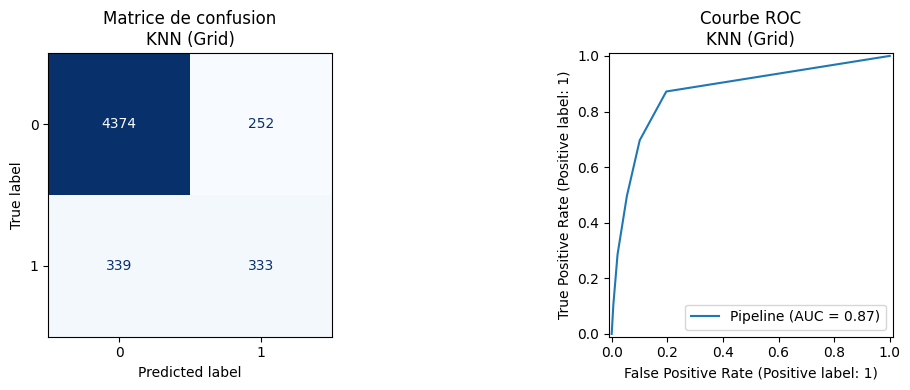

--- Random Search: KNN ---


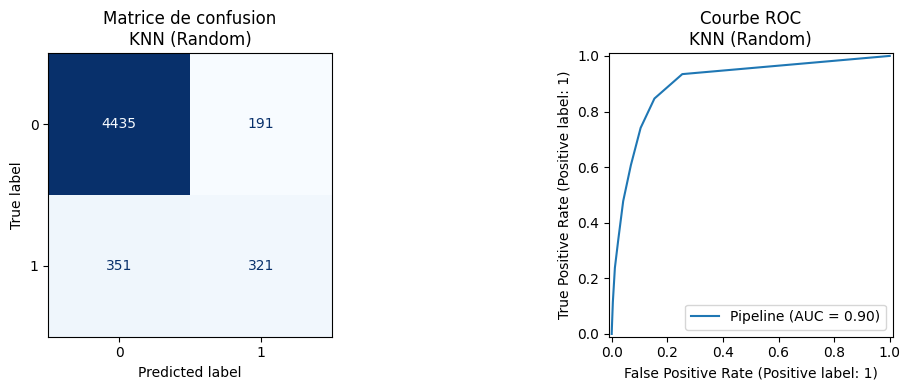

In [ ]:
knn_pipe = Pipeline([('pre', preprocessor), ('clf', KNeighborsClassifier())])
knn_params = {'clf__n_neighbors': [5, 9, 13, 17]}

results.append(grid_search_classif("KNN", knn_pipe, knn_params, X_train, y_train, X_test, y_test))
results.append(random_search_classif("KNN", knn_pipe, knn_params, X_train, y_train, X_test, y_test))

## 2. SVM

--- Grid Search: SVM ---


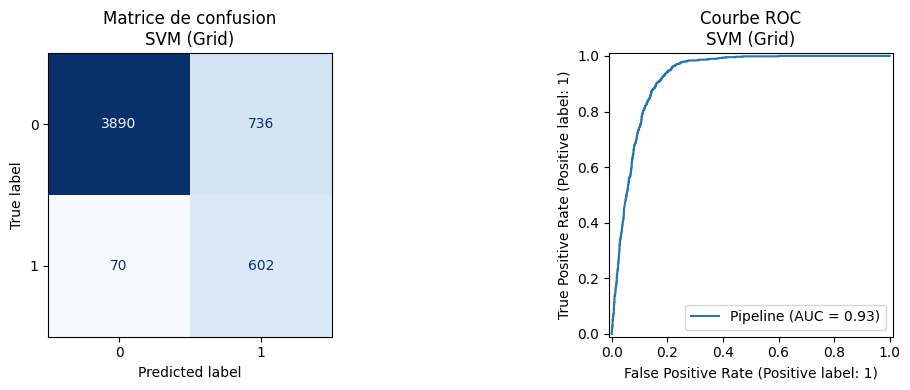

--- Random Search: SVM ---


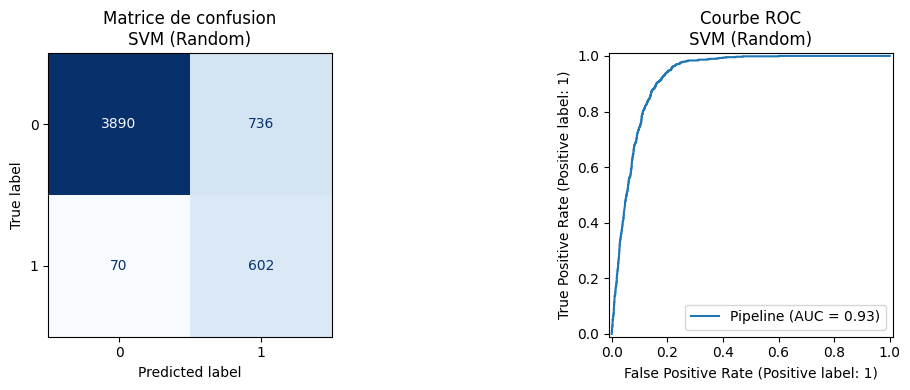

In [8]:
svm_pipe = Pipeline([('pre', preprocessor), ('clf', SVC(probability=True, class_weight='balanced'))])
svm_params = {'clf__C': [0.1, 1, 10], 'clf__kernel': ['rbf', 'linear']}

results.append(grid_search_classif("SVM", svm_pipe, svm_params, X_train, y_train, X_test, y_test))
results.append(random_search_classif("SVM", svm_pipe, svm_params, X_train, y_train, X_test, y_test))

## 3. Decision Tree

--- Grid Search: Decision Tree ---


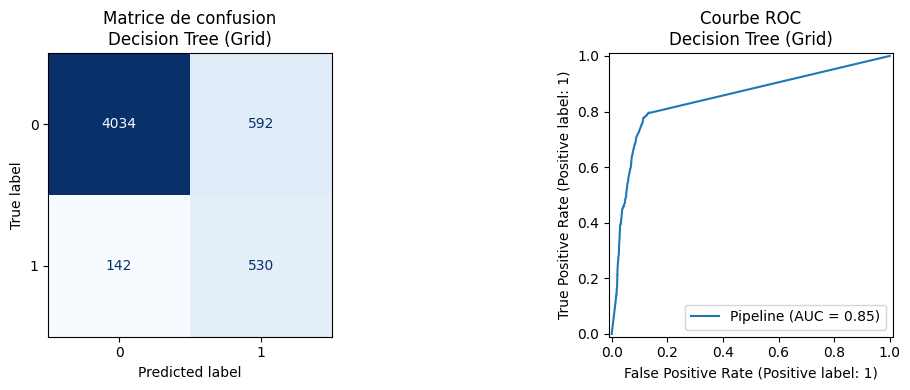

--- Random Search: Decision Tree ---


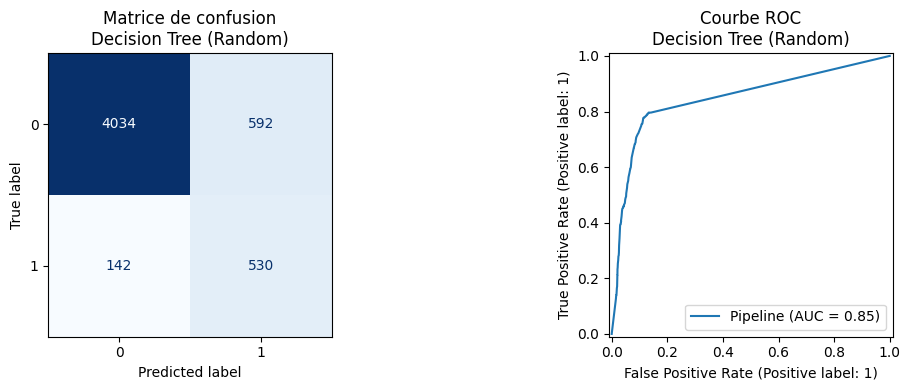

In [9]:
dt_pipe = Pipeline([('pre', preprocessor), ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))])
dt_params = {'clf__max_depth': [5, 10, 15], 'clf__min_samples_split': [2, 5, 10]}

results.append(grid_search_classif("Decision Tree", dt_pipe, dt_params, X_train, y_train, X_test, y_test))
results.append(random_search_classif("Decision Tree", dt_pipe, dt_params, X_train, y_train, X_test, y_test))

## 4. Random Forest

--- Grid Search: Random Forest ---


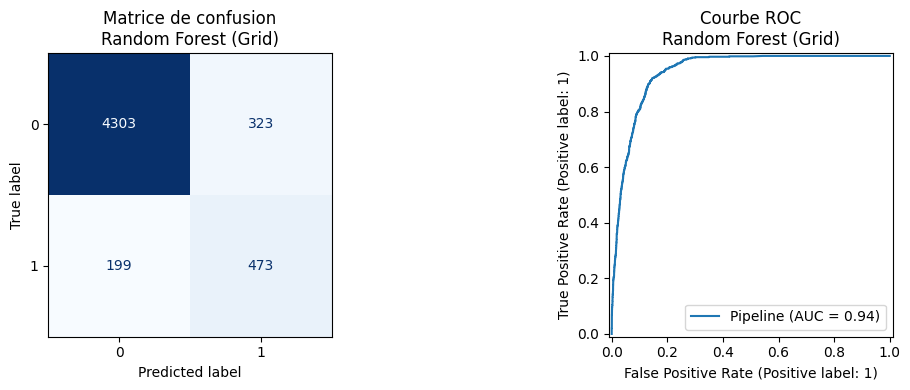

--- Random Search: Random Forest ---


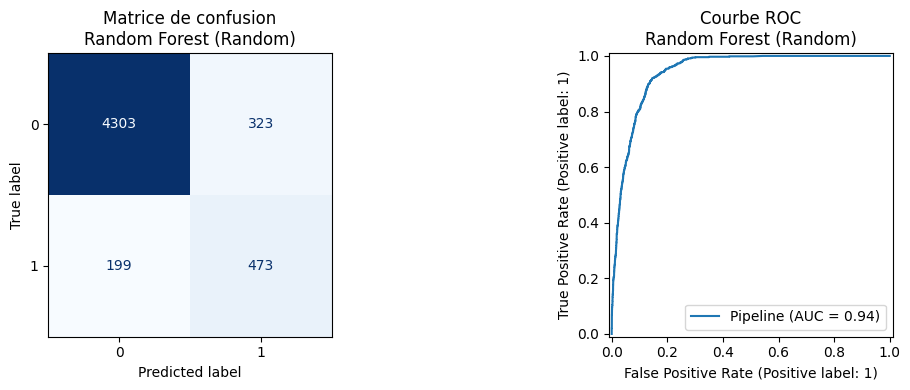

In [10]:
rf_pipe = Pipeline([('pre', preprocessor), ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))])
rf_params = {'clf__n_estimators': [50, 100], 'clf__max_depth': [10, 20]}

results.append(grid_search_classif("Random Forest", rf_pipe, rf_params, X_train, y_train, X_test, y_test))
results.append(random_search_classif("Random Forest", rf_pipe, rf_params, X_train, y_train, X_test, y_test))

## 5. XGBoost

--- Grid Search: XGBoost ---


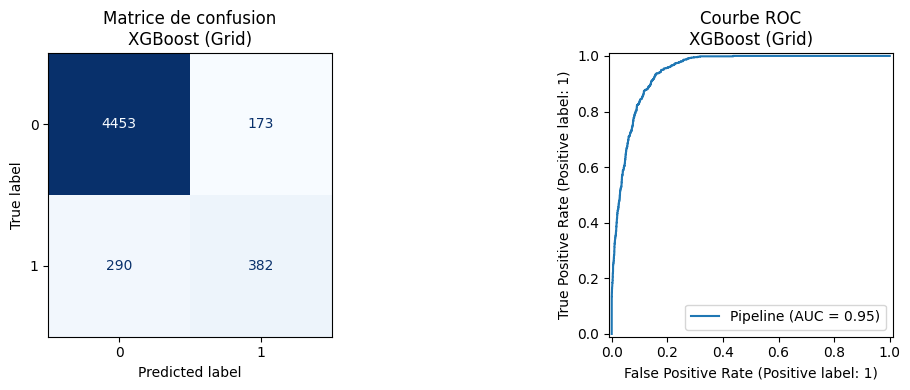

--- Random Search: XGBoost ---


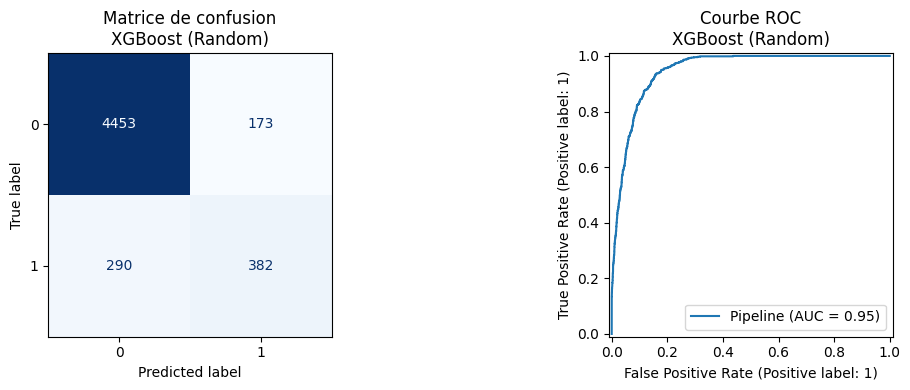

In [11]:
xgb_pipe = Pipeline([('pre', preprocessor), ('clf', XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE))])
xgb_params = {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.05, 0.1]}

results.append(grid_search_classif("XGBoost", xgb_pipe, xgb_params, X_train, y_train, X_test, y_test))
results.append(random_search_classif("XGBoost", xgb_pipe, xgb_params, X_train, y_train, X_test, y_test))

## Comparaison Finale

Synthèse des résultats (par F1-score pondéré) :


,model,search_type,best_params,duration,accuracy,precision,recall,f1,roc_auc
8,XGBoost,Grid,"{'clf__learning_rate': 0.05, 'clf__n_estimator...",4.326294,0.912609,0.688288,0.568452,0.908988,0.948407
9,XGBoost,Random,"{'clf__n_estimators': 100, 'clf__learning_rate...",1.989786,0.912609,0.688288,0.568452,0.908988,0.948407
6,Random Forest,Grid,"{'clf__max_depth': 20, 'clf__n_estimators': 100}",24.385378,0.901472,0.594221,0.703869,0.904964,0.943548
7,Random Forest,Random,"{'clf__n_estimators': 100, 'clf__max_depth': 20}",25.312905,0.901472,0.594221,0.703869,0.904964,0.943548
1,KNN,Random,{'clf__n_neighbors': 9},45.267183,0.897697,0.626953,0.477679,0.891654,0.901279
0,KNN,Grid,{'clf__n_neighbors': 5},23.185739,0.888448,0.569231,0.495536,0.885108,0.871133
4,Decision Tree,Grid,"{'clf__max_depth': 15, 'clf__min_samples_split...",2.386815,0.861457,0.472371,0.788690,0.875291,0.848451
5,Decision Tree,Random,"{'clf__min_samples_split': 2, 'clf__max_depth'...",2.197396,0.861457,0.472371,0.788690,0.875291,0.848451
2,SVM,Grid,"{'clf__C': 10, 'clf__kernel': 'rbf'}",225.215811,0.847867,0.449925,0.895833,0.867171,0.926663
3,SVM,Random,"{'clf__kernel': 'rbf', 'clf__C': 10}",238.435046,0.847867,0.449925,0.895833,0.867171,0.926638


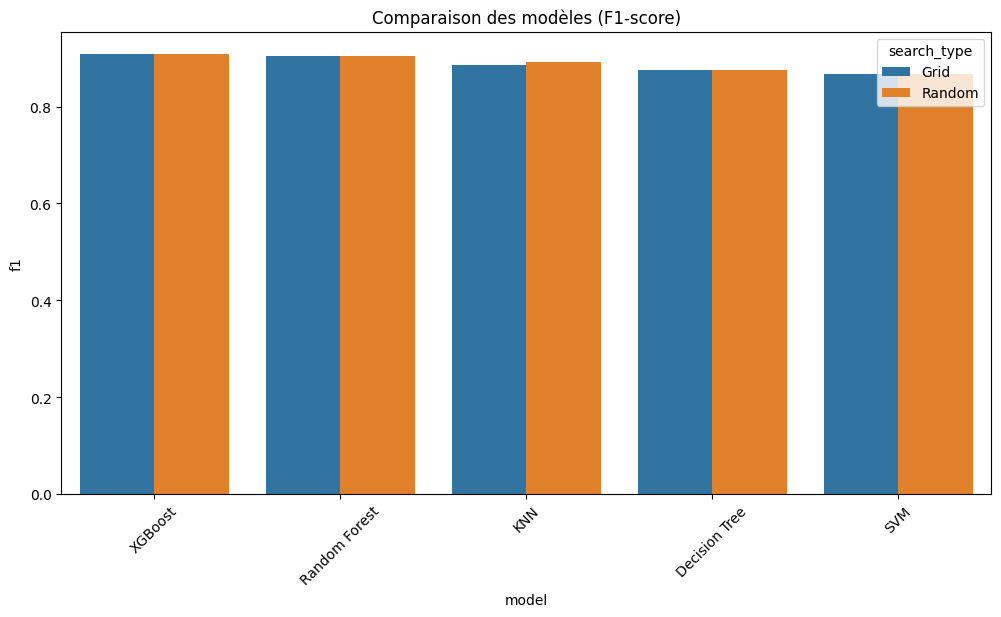

In [12]:
df_res = pd.DataFrame(results).sort_values(by='f1', ascending=False)
print("Synthèse des résultats (par F1-score pondéré) :")
display(df_res)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x='model', y='f1', hue='search_type')
plt.title("Comparaison des modèles (F1-score)")
plt.xticks(rotation=45)
plt.show()